# 1. Data Preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Loading the data set
df = pd.read_excel('/content/heart_disease.xlsx', sheet_name='Heart_disease')

In [ ]:
#Basic information
print(df.head())
print(df.columns)
print(df.info())


   age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
1   41  Male  atypical angina       135   203  False          normal     132   
2   57  Male     asymptomatic       140   192  False          normal     148   
3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak        slope          thal  num  
0  False      2.3  downsloping  fixed defect    0  
1  False      0.0         flat  fixed defect    0  
2  False      0.4         flat  fixed defect    0  
3  False      0.0         flat  fixed defect    0  
4   True      1.5         flat  fixed defect    0  
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entr

In [ ]:
# Clean column names
df.columns = df.columns.str.strip().str.lower()

In [ ]:
#num = 0 → no disease
#num = 1,2,3,4 → disease

In [ ]:
y = df['num'].apply(lambda x: 1 if x > 0 else 0)
X = df.drop('num', axis=1)


# 2. Data Cleaning

In [ ]:
# Convert to numeric (ignore non-numeric safely)
df = df.apply(pd.to_numeric, errors='coerce')

In [ ]:
# Fill missing values
df.fillna(df.mean(), inplace=True)

#3. EDA

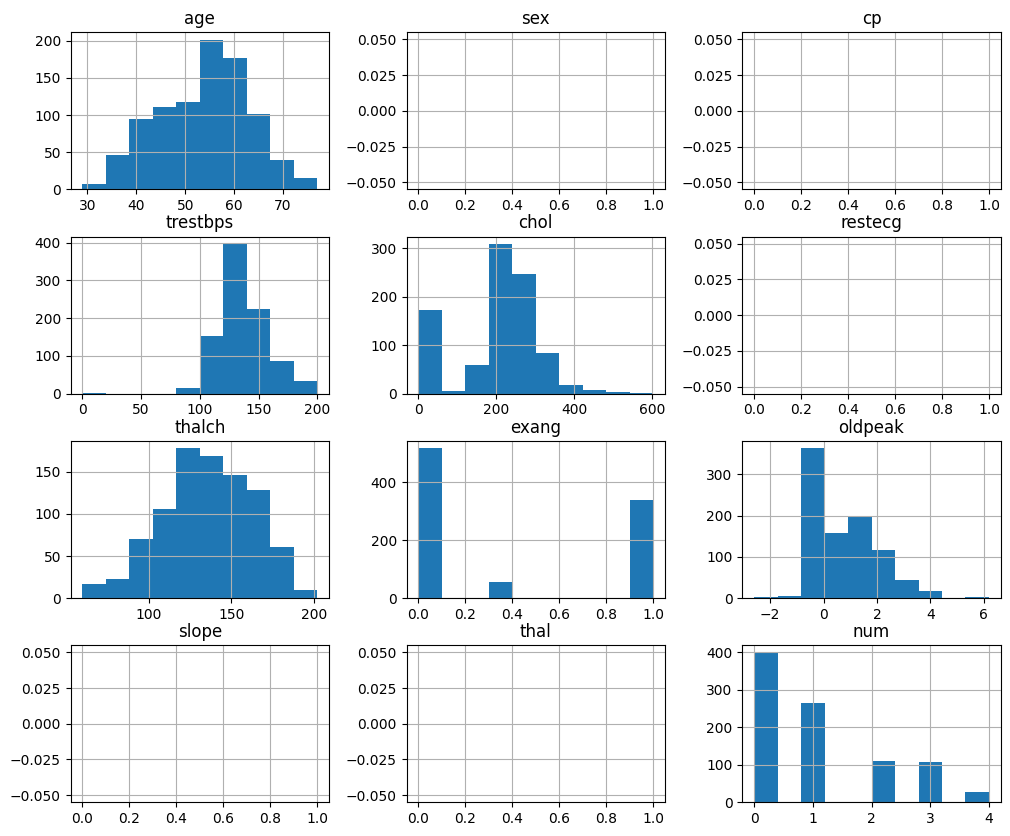

In [ ]:
# Histogram
df.hist(figsize=(12,10))
plt.show()

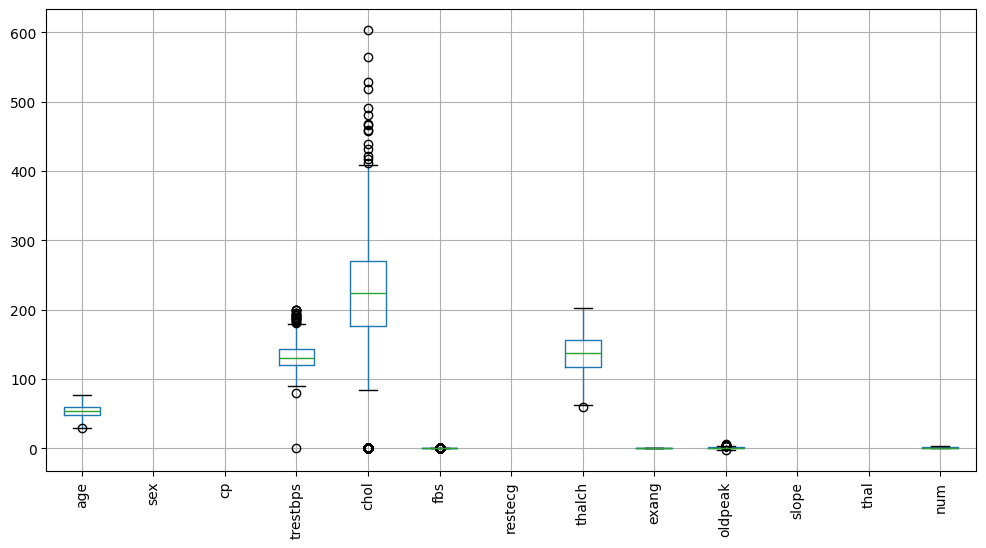

In [ ]:
# Boxplot
plt.figure(figsize=(12,6))
df.boxplot()
plt.xticks(rotation=90)
plt.show()

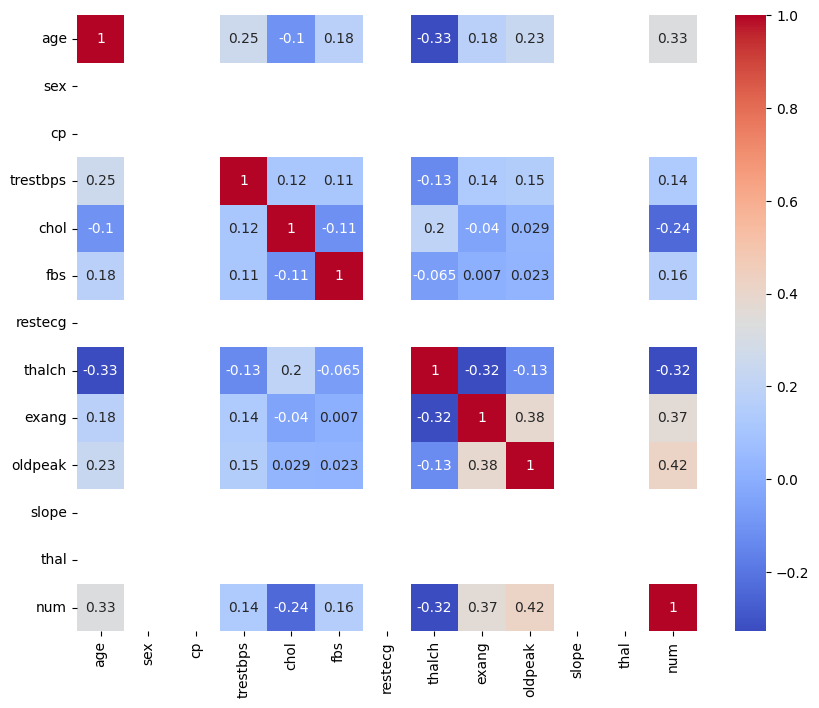

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


- The dataset contains medical features related to heart disease.
- Histograms show distribution of numerical features.
- Boxplots indicate presence of outliers.
- Correlation heatmap shows relationship between variables and target.


#4.Feature Engineering

In [ ]:
# Age grouping
df['age_group'] = pd.cut(df['age'], bins=[20,40,60,80], labels=[0,1,2])

- 'age_group' categorizes age into ranges.
- Helps capture non-linear patterns.


#5. Target Variable

In [ ]:
# Convert 'num' to binary (0 = no disease, 1 = disease)
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)


In [ ]:
# Features and target
X = df.drop(['num', 'target'], axis=1)
y = df['target']


# 6. Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 7. Model Building

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

# 8. Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.6813186813186813

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.67      0.67        89
           1       0.69      0.69      0.69        93

    accuracy                           0.68       182
   macro avg       0.68      0.68      0.68       182
weighted avg       0.68      0.68      0.68       182



#Model Analysis

- Decision Tree splits data based on feature importance.
- Tuned model reduces overfitting.
- Important features influence prediction.


# 9. Hyperparameter Tuning

In [ ]:
model_tuned = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=4,
    criterion='entropy',
    random_state=42
)

model_tuned.fit(X_train, y_train)

y_pred_tuned = model_tuned.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))



Tuned Accuracy: 0.7472527472527473


# 10. Confusion Matrix

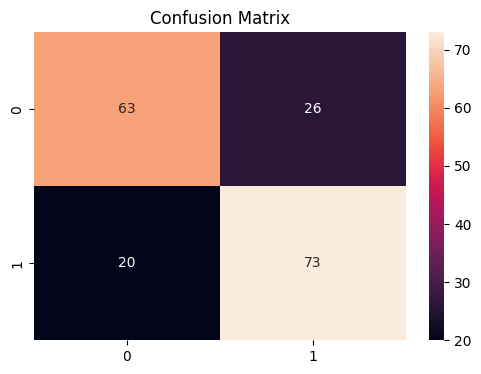

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_tuned), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# 11. Tree Visualization

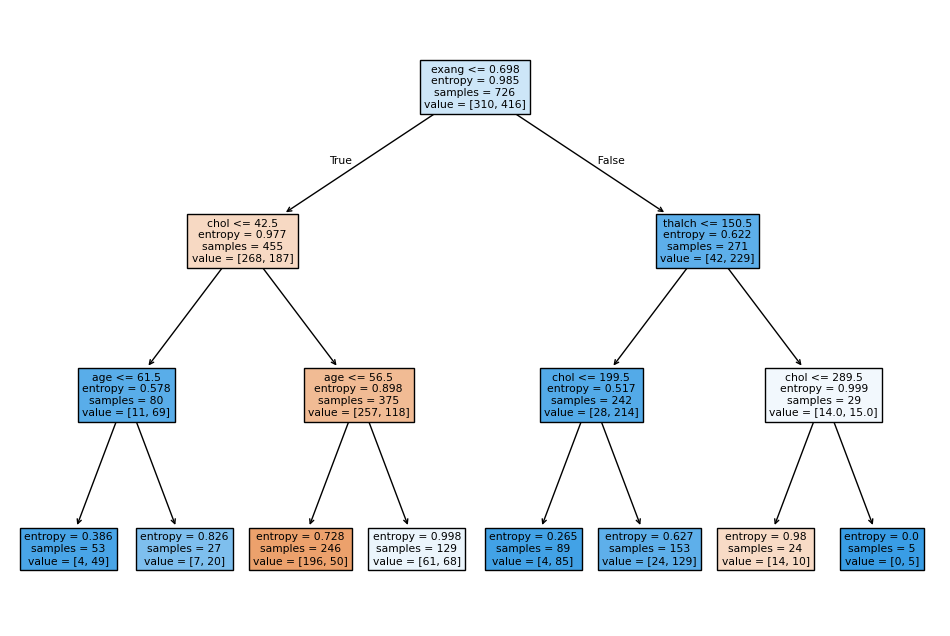

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(model_tuned, feature_names=X.columns, filled=True)
plt.show()

#Conclusion

- Decision Tree model successfully predicts heart disease.
- EDA helped understand feature relationships.
- Feature engineering improved performance.
- Hyperparameter tuning improved accuracy.

Overall, Decision Tree provides an interpretable classification model.


#Interview Questions:
##1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?


In Decision Tree models, hyperparameters control how the tree grows and how complex it becomes. Tuning them is important to balance overfitting vs underfitting.

Here are the most common ones:

1. max_depth
Controls the maximum depth of the tree.
Effect:
Small value → simpler model, may underfit
Large value → more complex, may overfit
2. min_samples_split
Minimum number of samples required to split a node.
Effect:
Higher value → prevents splits on small data, reduces overfitting
Lower value → allows more splits, can overfit
3. min_samples_leaf
Minimum number of samples required at a leaf node.
Effect:
Larger value → smoother model, reduces noise/overfitting
Smaller value → more detailed splits, may overfit
4. max_features
Number of features considered when looking for the best split.
Effect:
Fewer features → reduces overfitting, increases randomness
More features → stronger fit but higher overfitting risk
5. criterion
Function used to measure split quality.
Common options:
gini (Gini impurity)
entropy (information gain)
Effect:
Changes how the tree decides the “best” split
6. max_leaf_nodes
Limits the number of leaf nodes in the tree.
Effect:
Fewer leaves → simpler model, less overfitting
More leaves → more complex model
7. min_impurity_decrease
A split is made only if it reduces impurity by at least this value.
Effect:
Higher value → fewer splits, simpler tree
Lower value → more splits, complex tree

##2. What is the difference between the Label encoding and One-hot encoding?

#Difference between Label Encoding and One-Hot Encoding

Both are techniques used to convert categorical data into numerical form, but they work differently and are used in different situations.

#🔹 1. Label Encoding
Assigns a unique integer to each category.
Example:
Color	Label Encoding
Red	0
Blue	1
Green	2
# Key Points:
Simple and fast
Preserves order (which can be a problem)
Used when categories are ordinal (have natural order)
# Problem:
Model may think: Green (2) > Blue (1) > Red (0), even if no real order exists
#🔹 2. One-Hot Encoding
Creates a binary column for each category.
Example:
Color	Red	Blue	Green
Red	1	0	0
Blue	0	1	0
Green	0	0	1
# Key Points:
No ordering issue
Better for nominal data (no rank/order)
Common in machine learning models
#Problem:
Increases number of columns (high dimensionality)


####Use Label Encoding when there is a natural order (Low < Medium < High)
####Use One-Hot Encoding when categories are independent (Red, Blue, Green)